<a href="https://colab.research.google.com/github/SubashiniB181203/Computer_Vision_Lab/blob/main/221501145_CVA_exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
import cv2

In [ ]:
# Define image loading function
def load_images_from_directory(directory, target_size=(128, 128)):
    images = []
    labels = []
    for label_folder in os.listdir(directory):
        label_path = os.path.join(directory, label_folder)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                try:
                    img = load_img(img_path, target_size=target_size)
                    img_array = img_to_array(img)
                    images.append(img_array)
                    labels.append(label_folder)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
    return images, labels

In [ ]:
# Load images and labels
data_directory = "/content/drive/MyDrive/Dataset"
images, labels = load_images_from_directory(data_directory)

In [ ]:
# Convert lists to numpy arrays
images = np.array(images, dtype='float32')

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
labels = to_categorical(labels)

In [ ]:
# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
# Normalize pixel values to [0, 1]
X_train /= 255.0
X_test /= 255.0

In [ ]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [ ]:
# Define CNN model
def build_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
# Compile the model
input_shape = X_train.shape[1:]  # (128, 128, 3)
num_classes = y_train.shape[1]
model = build_cnn_model(input_shape, num_classes)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                     epochs=20, validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4365 - loss: 0.7687 - val_accuracy: 0.4000 - val_loss: 0.7540
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.5151 - loss: 0.7188 - val_accuracy: 0.4000 - val_loss: 0.7271
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5594 - loss: 0.6831 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6073 - loss: 0.6737 - val_accuracy: 0.6000 - val_loss: 0.6772
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5573 - loss: 0.6987 - val_accuracy: 0.7000 - val_loss: 0.6724
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6958 - loss: 0.6657 - val_accuracy: 0.5000 - val_loss: 0.6835
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6219 - loss: 0.6658 - val_accuracy: 0.4500 - val_loss: 0.7013
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - accuracy: 0.5536 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 9/20
3

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step - accuracy: 0.6000 - loss: 0.6372
Test Loss: 0.6372
Test Accuracy: 60.00%


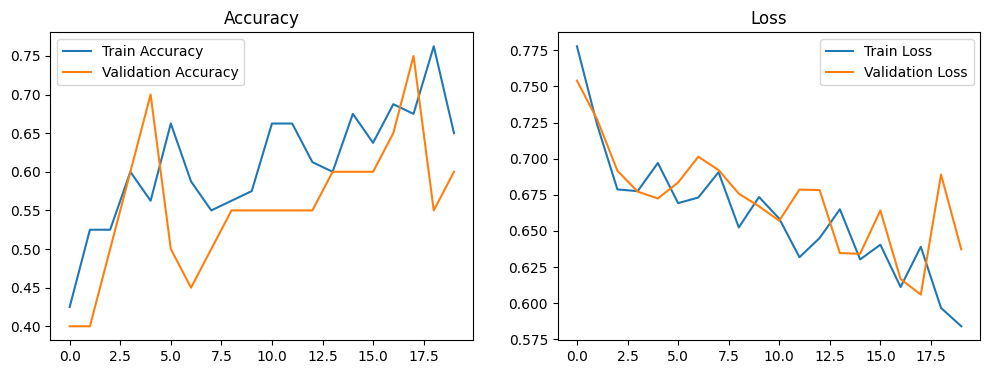

In [ ]:
# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


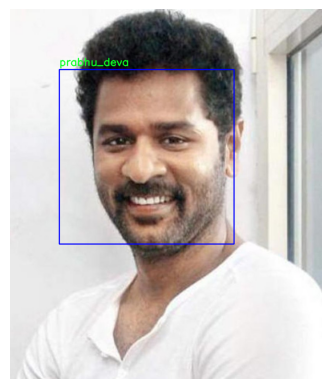

Predicted Label: prabhu_deva
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


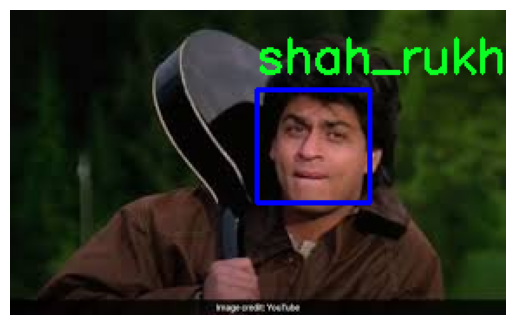

Predicted Label: shah_rukh_khan


In [ ]:
# Real-time face detection and labeling
def detect_and_label_faces(image_path, model, label_encoder):
    # Load the image and convert to array
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_array = img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict the label
    predictions = model.predict(img_array)
    predicted_label = label_encoder.inverse_transform([np.argmax(predictions)])[0]

    # Detect face using Haar Cascade
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, 1.1, 4)

    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        # Put the label text above the rectangle
        cv2.putText(img, predicted_label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

    # Display the image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    return predicted_label  # Return the predicted label

# Example usage
image_path1 = "/content/drive/MyDrive/Dataset/prabhu_deva/16fa5efde4.jpg"
image_path2 = "/content/drive/MyDrive/Dataset/shah_rukh_khan/4d90377ca8.jpg"
predicted_label1 = detect_and_label_faces(image_path1, model, label_encoder)  # Call the function and assign the return value
print(f"Predicted Label: {predicted_label1}")
predicted_label2 = detect_and_label_faces(image_path2, model, label_encoder)  # Call the function and assign the return value
print(f"Predicted Label: {predicted_label2}")